# Classification Track — Part A
## 03. Naive Bayes (Gaussian)

**Notes from the algorithm list:** Discuss conditional independence assumption.

Gaussian Naive Bayes assumes every feature is conditionally independent of every other feature *given the class
label*, and that each feature follows a Gaussian distribution within each class. This is a strong assumption
that is almost certainly violated here — e.g. `Weight` and `BMI` are, by construction, highly correlated with
each other and with `Height` — but Naive Bayes is included as a fast, simple probabilistic baseline to see how
much accuracy is lost by ignoring feature correlations entirely.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize
import os

RANDOM_STATE = 42
sns.set_style("whitegrid")

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")
class_map = pd.read_csv("../data/processed/class_mapping.csv", index_col=0)["class_name"].to_dict()
class_names = [class_map[i] for i in sorted(class_map.keys())]

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Classes:", class_names)

X_train: (1688, 21)  X_test: (423, 21)
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


In [2]:
ALGO_KEY = "naive_bayes"
ALGO_DISPLAY = "Naive Bayes (Gaussian)"

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
print("Model trained.")

Model trained.


**On the independence assumption:** despite `BMI` being mathematically derived from `Weight` and `Height`
(so all three are strongly correlated), Naive Bayes treats them as three separate, independent pieces of evidence
and effectively "double counts" the same underlying signal. This is expected to inflate its confidence without
necessarily improving its accuracy relative to models that can account for feature interactions (e.g. tree-based
or kernel-based models) — a useful contrast to point out in the final comparison table.

### Evaluation

In [3]:
y_pred = nb.predict(X_test)
y_proba = nb.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(class_map.keys()))
roc_auc_ovr = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='weighted')

print(f"Accuracy           : {acc:.4f}")
print(f"Weighted Precision  : {precision_weighted:.4f}")
print(f"Weighted Recall     : {recall_weighted:.4f}")
print(f"Weighted F1-score   : {f1_weighted:.4f}")
print(f"ROC-AUC (OvR, wtd)  : {roc_auc_ovr:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Accuracy           : 0.7447
Weighted Precision  : 0.7849
Weighted Recall     : 0.7447
Weighted F1-score   : 0.7351
ROC-AUC (OvR, wtd)  : 0.9497

Full classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.74      0.98      0.84        54
      Normal_Weight       0.65      0.38      0.48        58
     Obesity_Type_I       0.95      0.50      0.65        70
    Obesity_Type_II       0.52      0.93      0.67        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.73      0.84      0.78        58
Overweight_Level_II       0.86      0.62      0.72        58

           accuracy                           0.74       423
          macro avg       0.78      0.75      0.73       423
       weighted avg       0.78      0.74      0.74       423



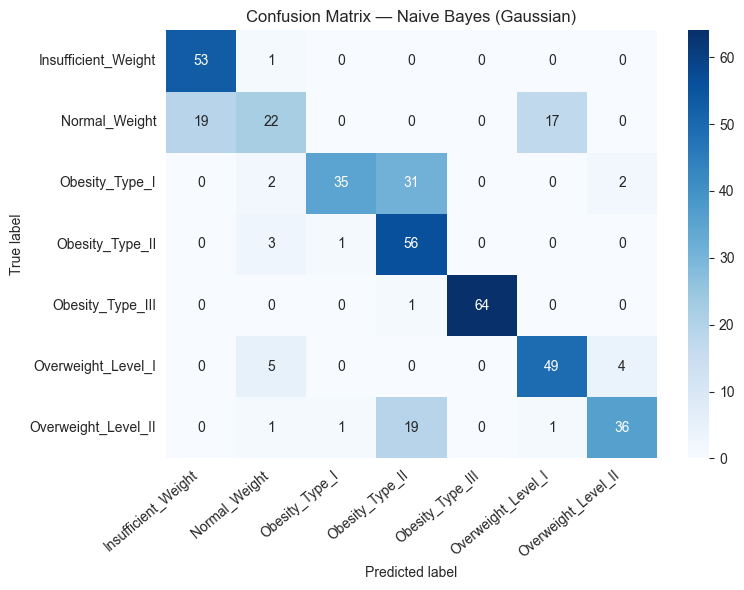

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix — {ALGO_DISPLAY}")
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"../results/fig_confusion_matrix_{ALGO_KEY}.png", bbox_inches="tight")
plt.show()

In [5]:
results_path = "../results/part_a_results.csv"
row = pd.DataFrame([{
    "Algorithm": ALGO_DISPLAY,
    "Accuracy": round(acc, 4),
    "Precision_weighted": round(precision_weighted, 4),
    "Recall_weighted": round(recall_weighted, 4),
    "F1_weighted": round(f1_weighted, 4),
    "ROC_AUC_OvR": round(roc_auc_ovr, 4),
}])

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing["Algorithm"] != ALGO_DISPLAY]
    combined = pd.concat([existing, row], ignore_index=True)
else:
    combined = row

combined.to_csv(results_path, index=False)
print("Logged result to part_a_results.csv:")
combined

Logged result to part_a_results.csv:


,Algorithm,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC_OvR
0,Decision Tree,0.9811,0.9814,0.9811,0.9810,0.9955
1,Support Vector Machine (SVC),0.9764,0.9773,0.9764,0.9765,0.9989
2,Logistic Regression,0.9078,0.9088,0.9078,0.9071,0.9921
3,K-Nearest Neighbors,0.9243,0.9230,0.9243,0.9229,0.9864
4,Naive Bayes (Gaussian),0.7447,0.7849,0.7447,0.7351,0.9497
